# Registration
Plots for the registration steps

In [1]:
# Imports and general options
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
# Matplotlib options
plt.rcParams["font.family"] = "Arial"

In [3]:
# Data and save paths
save_root = Path("../data/figures/paper/registration")
save_root.mkdir(exist_ok=True, parents=True)
root = Path("../data/processed/aligned/Au_01-vol_01/")

In [4]:
# Functions
def get_loss_item(loss_history: np.ndarray, idx: int) -> pd.DataFrame:
    loss_item = pd.DataFrame(loss_history[idx], columns=["level", "metric"]).dropna()
    loss_item["step"] = loss_item.index + 1
    return loss_item

## Loss per image pair

In [5]:
# Load data
results = np.load(root / "registration_results.npz")
loss_history = results["loss_history"]

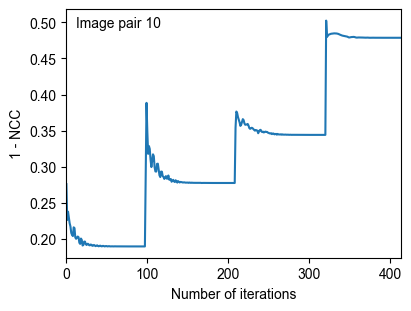

In [6]:
# Loss history for given pair
# pair_idx = 271
pair_idx = 10

fig, ax = plt.subplots(layout="constrained", figsize=(4, 3))

loss_item = get_loss_item(loss_history, pair_idx)
ax.plot(loss_item["metric"])
ax.set(xlim=[0, len(loss_item)], xlabel="Number of iterations", ylabel="1 - NCC")
ax.text(
    x=0.03,
    y=0.97,
    s=f"Image pair {pair_idx}",
    transform=ax.transAxes,
    verticalalignment="top",
    horizontalalignment="left",
)

fig.savefig(
    save_root / f"Registration-loss-history-pair_{pair_idx}.pdf",
    bbox_inches="tight",
    pad_inches=0.01,
)

## Overview of metrics

In [7]:
# Load and parse data
with open(root / "registration_log.json") as file:
    logs = json.load(file)
logs = pd.DataFrame(logs)

with open(root / "initial_losses.json") as file:
    initial_loss = json.load(file)

logs = logs.merge(pd.DataFrame(initial_loss))
logs["loss_delta"] = logs["final_loss"] / logs["initial_loss"] - 1
logs["ncc_delta"] = -logs["loss_delta"]

In [8]:
# Make long dataframe for seaborn
logs_long = pd.melt(
    logs,
    id_vars=["pair_index_start", "fixed_image_path", "moving_image_path"],
    value_vars=["initial_loss", "final_loss"],
    var_name="loss_type",
    value_name="loss",
)
logs_long["ncc"] = 1 - logs_long["loss"]

# Make variable names more legible for auto legend
value_map = {"initial_loss": "Before registration", "final_loss": "After registration"}
logs_long["loss_type_clean"] = logs_long["loss_type"].replace(value_map)

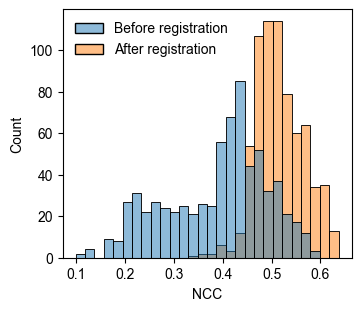

In [9]:
# Plot NCC distribution
fig, ax = plt.subplots(layout="constrained", figsize=(3.5, 3))
sns.histplot(data=logs_long, x="ncc", ax=ax, hue="loss_type_clean")
ax.set(xlabel="NCC")

leg = ax.get_legend()
leg.set(title="", frame_on=False)
# for text in leg.get_texts():
#     text.set_fontsize(8)
fig.savefig(
    save_root / "Registration-ncc-histogram.pdf", bbox_inches="tight", pad_inches=0.01
)

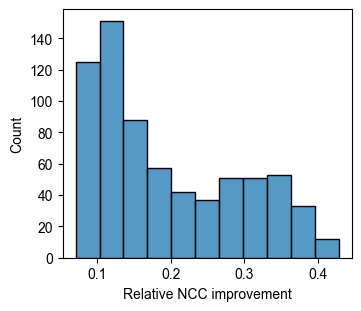

In [10]:
# Plot loss improvement
fig, ax = plt.subplots(layout="constrained", figsize=(3.5, 3))
sns.histplot(data=logs, x="ncc_delta", ax=ax)
ax.set(xlabel="Relative NCC improvement")

fig.savefig(
    save_root / "Registration-improvement-histogram.pdf",
    bbox_inches="tight",
    pad_inches=0.01,
)

In [11]:
logs.loc[logs["ncc_delta"].idxmax()]

pair_index_start                         686
fixed_image_path     Au_01-vol_01-z_1137.tif
moving_image_path    Au_01-vol_01-z_1138.tif
final_loss                          0.423403
num_steps_taken                          388
initial_loss                        0.740183
loss_delta                         -0.427975
ncc_delta                           0.427975
Name: 686, dtype: object